In [13]:
import mne
import numpy as np
import pandas as pd
from pathlib import Path

data_path = Path("/Users/jininaljayyousi/mindclick/data/raw/B_01_SE001_CB_Train06.edf")

raw = mne.io.read_raw_edf(data_path, preload=True)
print(raw)

Extracting EDF parameters from /Users/jininaljayyousi/mindclick/data/raw/B_01_SE001_CB_Train06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 40455  =      0.000 ...   158.027 secs...
<RawEDF | B_01_SE001_CB_Train06.edf, 62 x 40456 (158.0 s), ~19.2 MiB, data loaded>


/var/folders/1k/m00ckqlx5cn3hklkwvwxq6wc0000gn/T/ipykernel_12643/1788958187.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(data_path, preload=True)
/var/folders/1k/m00ckqlx5cn3hklkwvwxq6wc0000gn/T/ipykernel_12643/1788958187.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(data_path, preload=True)


In [6]:
print(raw.ch_names)
print(raw.get_channel_types())

['EEG_F3', 'EEG_Fz', 'EEG_F4', 'EEG_T7', 'EEG_C3', 'EEG_Cz', 'EEG_C4', 'EEG_T8', 'EEG_CP3', 'EEG_CP4', 'EEG_P3', 'EEG_Pz', 'EEG_P4', 'EEG_PO7', 'EEG_PO8', 'EEG_Oz', 'A_1_1', 'B_1_2', 'C_1_3', 'D_1_4', 'E_1_5', 'F_1_6', 'G_2_1', 'H_2_2', 'I_2_3', 'J_2_4', 'K_2_5', 'L_2_6', 'M_3_1', 'N_3_2', 'O_3_3', 'P_3_4', 'Q_3_5', 'R_3_6', 'S_4_1', 'T_4_2', 'U_4_3', 'V_4_4', 'W_4_5', 'X_4_6', 'Y_5_1', 'Z_5_2', 'Sp_5_3', '1_5_4', '2_5_5', '3_5_6', '4_6_1', '5_6_2', '6_6_3', '7_6_4', '8_6_5', '9_6_6', 'StimulusType', 'SelectedTarget', 'SelectedRow', 'SelectedColumn', 'PhaseInSequence', 'StimulusBegin', 'StimulusCode', 'CurrentTarget', 'FakeFeedback', 'DisplayResults']
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'ee

Using matplotlib as 2D backend.


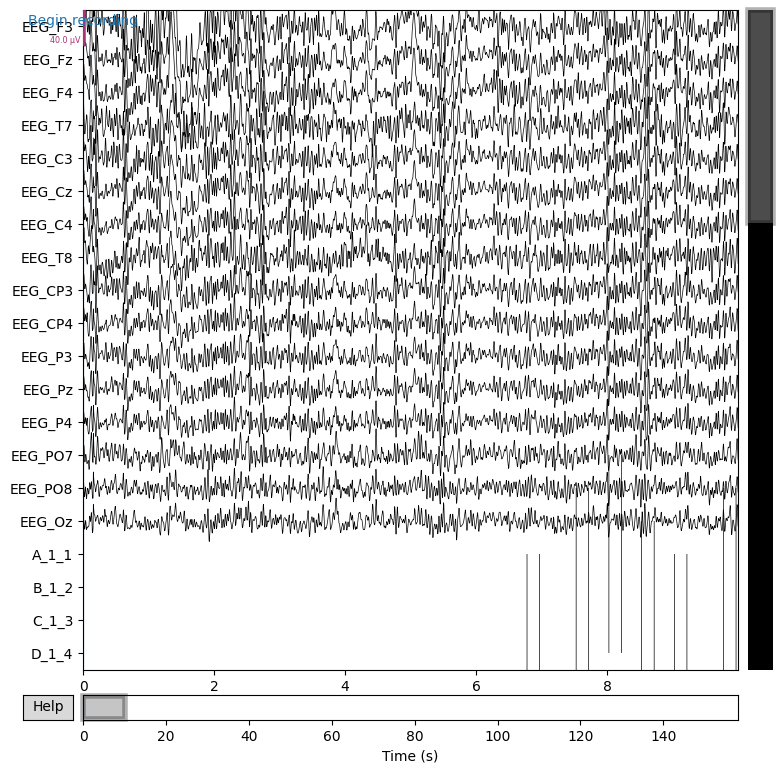

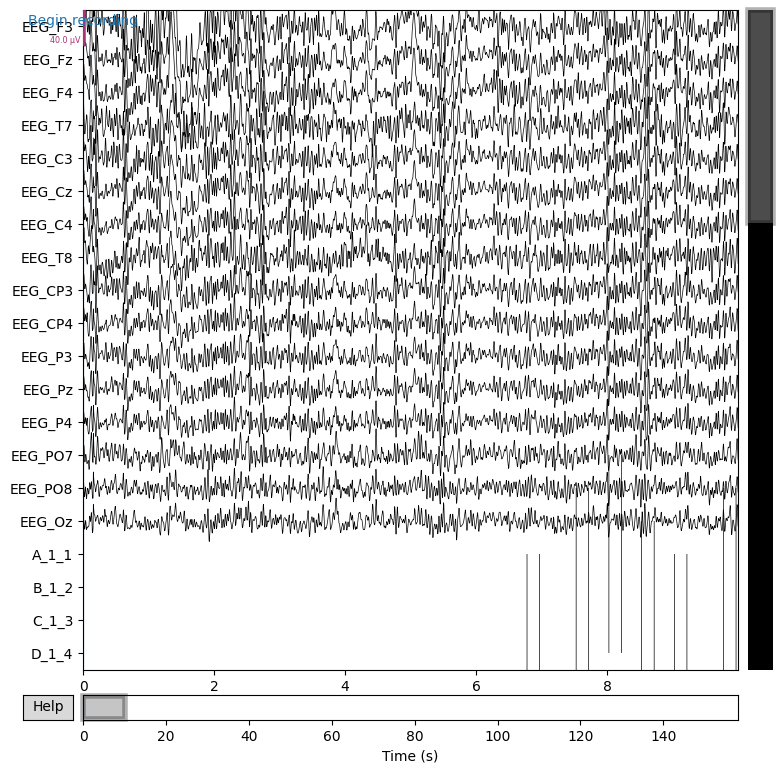

In [3]:
raw.plot()

In [ ]:
stimulus_channels = [
    "StimulusType",
    "SelectedTarget",
    "SelectedRow",
    "SelectedColumn",
    "PhaseInSequence",
    "StimulusBegin",
    "StimulusCode",
    "CurrentTarget",
    "FakeFeedback",
    "DisplayResults",
]

for channel_name in stimulus_channels:
    data = raw.copy().pick([channel_name]).get_data().squeeze()
    print(channel_name, "min =", data.min(), "max =", data.max(), "unique sample =", np.unique(data[:5000])[:20])

StimulusType min = 0.0 max = 1.0 unique sample = [0. 1.]
SelectedTarget min = 0.0 max = 20.0 unique sample = [0.]
SelectedRow min = 0.0 max = 4.0 unique sample = [0.]
SelectedColumn min = 0.0 max = 6.0 unique sample = [0.]
PhaseInSequence min = 0.0 max = 3.0 unique sample = [0. 1. 2.]
StimulusBegin min = 0.0 max = 1.0 unique sample = [0. 1.]
StimulusCode min = 0.0 max = 640.0 unique sample = [  0. 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167.
 168. 169. 170. 171. 172. 191.]
CurrentTarget min = 0.0 max = 20.0 unique sample = [ 0. 20.]
FakeFeedback min = 0.0 max = 0.0 unique sample = [0.]
DisplayResults min = 0.0 max = 0.0 unique sample = [0.]


From this, I deduced that StimulusCode is the flash identity channel, that corresponds to a row flash or a column flash.
StimulusBegin is the event timing signal. 1 means flash, 0 means no flash. 

In [8]:
raw_events = raw.copy()

raw_events.set_channel_types({
    "StimulusBegin": "stim",
})

events = mne.find_events(raw_events, stim_channel="StimulusBegin")
print(events[:20])

Finding events on: StimulusBegin
540 events found on stim channel StimulusBegin
Event IDs: [1]
[[1672    0    1]
 [1736    0    1]
 [1800    0    1]
 [1864    0    1]
 [1928    0    1]
 [1992    0    1]
 [2056    0    1]
 [2120    0    1]
 [2184    0    1]
 [2248    0    1]
 [2312    0    1]
 [2376    0    1]
 [2440    0    1]
 [2504    0    1]
 [2568    0    1]
 [2632    0    1]
 [2696    0    1]
 [2760    0    1]
 [2824    0    1]
 [2888    0    1]]


In [9]:
event_samples = events[:, 0]
stimulus_code = raw.get_data(picks=["StimulusCode"]).squeeze()

event_codes = stimulus_code[event_samples]

print(event_codes[:50])

[159. 155. 158. 157. 156. 164. 160. 161. 162. 163. 165. 167. 168. 166.
 169. 170. 172. 171. 192. 195. 194. 191. 193. 196. 198. 200. 197. 199.
 201. 204. 202. 203. 207. 208. 205. 206. 245. 247. 248. 246. 249. 254.
 250. 253. 252. 251. 258. 257. 256. 255.]


In [11]:
unique_codes = sorted(np.unique(event_codes))
print(unique_codes)

[np.float64(101.0), np.float64(102.0), np.float64(103.0), np.float64(104.0), np.float64(105.0), np.float64(106.0), np.float64(107.0), np.float64(108.0), np.float64(109.0), np.float64(110.0), np.float64(111.0), np.float64(112.0), np.float64(113.0), np.float64(114.0), np.float64(115.0), np.float64(116.0), np.float64(117.0), np.float64(118.0), np.float64(119.0), np.float64(120.0), np.float64(121.0), np.float64(122.0), np.float64(123.0), np.float64(124.0), np.float64(125.0), np.float64(126.0), np.float64(127.0), np.float64(128.0), np.float64(129.0), np.float64(130.0), np.float64(131.0), np.float64(132.0), np.float64(133.0), np.float64(134.0), np.float64(135.0), np.float64(136.0), np.float64(137.0), np.float64(138.0), np.float64(139.0), np.float64(140.0), np.float64(141.0), np.float64(142.0), np.float64(143.0), np.float64(144.0), np.float64(145.0), np.float64(146.0), np.float64(147.0), np.float64(148.0), np.float64(149.0), np.float64(150.0), np.float64(151.0), np.float64(152.0), np.float64(

Actually, I take it back. This output showed me that relying on StimulusCode for the flashes was not the cleanest way to go about it.

The truth is that the correct next step is to use the character presentation channels as the actual flash identity source. StimulusBegin gives the event times, and StimulusType tells you whether that flash was a target stimulus or a non target stimulus. The 36 character presentation channels are which characters were lit during that flash.


STARTING OVER. 

In [14]:
import mne
import numpy as np
import pandas as pd
from pathlib import Path

In [15]:
data_path = Path("/Users/jininaljayyousi/mindclick/data/raw/B_01_SE001_CB_Train06.edf")

raw = mne.io.read_raw_edf(data_path, preload=True)
print(raw)

Extracting EDF parameters from /Users/jininaljayyousi/mindclick/data/raw/B_01_SE001_CB_Train06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 40455  =      0.000 ...   158.027 secs...
<RawEDF | B_01_SE001_CB_Train06.edf, 62 x 40456 (158.0 s), ~19.2 MiB, data loaded>


/var/folders/1k/m00ckqlx5cn3hklkwvwxq6wc0000gn/T/ipykernel_12643/1521606040.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(data_path, preload=True)
/var/folders/1k/m00ckqlx5cn3hklkwvwxq6wc0000gn/T/ipykernel_12643/1521606040.py:3: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(data_path, preload=True)


In [16]:
character_channels = [
    "A_1_1", "B_1_2", "C_1_3", "D_1_4", "E_1_5", "F_1_6",
    "G_2_1", "H_2_2", "I_2_3", "J_2_4", "K_2_5", "L_2_6",
    "M_3_1", "N_3_2", "O_3_3", "P_3_4", "Q_3_5", "R_3_6",
    "S_4_1", "T_4_2", "U_4_3", "V_4_4", "W_4_5", "X_4_6",
    "Y_5_1", "Z_5_2", "Sp_5_3", "1_5_4", "2_5_5", "3_5_6",
    "4_6_1", "5_6_2", "6_6_3", "7_6_4", "8_6_5", "9_6_6",
]

In [17]:
stimulus_channels = [
    "StimulusType",
    "SelectedTarget",
    "SelectedRow",
    "SelectedColumn",
    "PhaseInSequence",
    "StimulusBegin",
    "StimulusCode",
    "CurrentTarget",
    "FakeFeedback",
    "DisplayResults",
]

In [18]:
raw_events = raw.copy()
raw_events.set_channel_types({"StimulusBegin": "stim"})

events = mne.find_events(raw_events, stim_channel="StimulusBegin")

print("Number of events:", len(events))
print(events[:10])

Finding events on: StimulusBegin
540 events found on stim channel StimulusBegin
Event IDs: [1]
Number of events: 540
[[1672    0    1]
 [1736    0    1]
 [1800    0    1]
 [1864    0    1]
 [1928    0    1]
 [1992    0    1]
 [2056    0    1]
 [2120    0    1]
 [2184    0    1]
 [2248    0    1]]


In [19]:
all_channels = character_channels + stimulus_channels

channel_data = raw.copy().pick(all_channels).get_data()

channel_index = {
    name: idx for idx, name in enumerate(all_channels)
}

In [20]:
flash_rows = []

for flash_index, event in enumerate(events):
    sample_index = int(event[0])

    active_character_channels = [
        ch
        for ch in character_channels
        if channel_data[channel_index[ch], sample_index] > 0.5
    ]

    flash_rows.append({
        "flash_index": flash_index,
        "sample_index": sample_index,
        "stimulus_code": int(channel_data[channel_index["StimulusCode"], sample_index]),
        "stimulus_type": int(channel_data[channel_index["StimulusType"], sample_index]),
        "current_target": int(channel_data[channel_index["CurrentTarget"], sample_index]),
        "selected_target": int(channel_data[channel_index["SelectedTarget"], sample_index]),
        "selected_row": int(channel_data[channel_index["SelectedRow"], sample_index]),
        "selected_column": int(channel_data[channel_index["SelectedColumn"], sample_index]),
        "phase": int(channel_data[channel_index["PhaseInSequence"], sample_index]),
        "active_channels": active_character_channels,
        "active_count": len(active_character_channels),
    })

In [21]:
flash_table = pd.DataFrame(flash_rows)

flash_table.head(20)

,flash_index,sample_index,stimulus_code,stimulus_type,current_target,selected_target,selected_row,selected_column,phase,active_channels,active_count
0,0,1672,159,0,20,0,0,0,2,"[I_2_3, Z_5_2, 8_6_5]",3
1,1,1736,155,0,20,0,0,0,2,"[D_1_4, P_3_4, R_3_6, 6_6_3]",4
2,2,1800,158,0,20,0,0,0,2,"[F_1_6, K_2_5, 3_5_6, 4_6_1]",4
3,3,1864,157,0,20,0,0,0,2,"[N_3_2, S_4_1, W_4_5]",3
4,4,1928,156,0,20,0,0,0,2,"[B_1_2, G_2_1, U_4_3, 1_5_4]",4
5,5,1992,164,0,20,0,0,0,2,"[E_1_5, H_2_2, Sp_5_3]",3
6,6,2056,160,0,20,0,0,0,2,"[A_1_1, J_2_4, V_4_4, Y_5_1]",4
7,7,2120,161,0,20,0,0,0,2,"[Q_3_5, 5_6_2, 7_6_4]",3
8,8,2184,162,0,20,0,0,0,2,"[C_1_3, M_3_1, X_4_6, 2_5_5]",4
9,9,2248,163,1,20,0,0,0,2,"[L_2_6, O_3_3, T_4_2, 9_6_6]",4


current_target is constant at 20 for this portion of the recording, while stimulus_type switches between 0 and 1. That means the target is fixed and the flashes are being presented in a sequence around that target. 

In [22]:
print("Stimulus types:", sorted(flash_table["stimulus_type"].unique()))
print("Phases:", sorted(flash_table["phase"].unique()))
print("Active counts:", sorted(flash_table["active_count"].unique()))

Stimulus types: [np.int64(0), np.int64(1)]
Phases: [np.int64(2)]
Active counts: [np.int64(3), np.int64(4), np.int64(5)]


In [24]:
processed_directory = Path("/Users/jininaljayyousi/mindclick/data/processed")
processed_directory.mkdir(parents=True, exist_ok=True)

flash_table_export = flash_table.copy()

flash_table_export["active_channels"] = flash_table_export["active_channels"].apply(
    lambda value: "|".join(value)
)

output_path = processed_directory / "flash_table.csv"
flash_table_export.to_csv(output_path, index=False)

print(f"Saved flash table to: {output_path}")
print(flash_table_export.head(5))

Saved flash table to: /Users/jininaljayyousi/mindclick/data/processed/flash_table.csv
   flash_index  sample_index  stimulus_code  stimulus_type  current_target  \
0            0          1672            159              0              20   
1            1          1736            155              0              20   
2            2          1800            158              0              20   
3            3          1864            157              0              20   
4            4          1928            156              0              20   

   selected_target  selected_row  selected_column  phase  \
0                0             0                0      2   
1                0             0                0      2   
2                0             0                0      2   
3                0             0                0      2   
4                0             0                0      2   

           active_channels  active_count  
0        I_2_3|Z_5_2|8_6_5             3 